# **BurnAway AI — Developer Burnout Prediction System**

# 1. Environment Setup

In [ ]:
# Standard Library
import json as _json
import os
import warnings
from datetime import datetime
from pathlib import Path

# Third-Party: Data & Preprocessing
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

# Scikit-Learn & Imbalanced-Learn
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, Model

# Google GenAI SDK (opsional)
try:
    from google import genai
    GENAI_SDK_AVAILABLE = True
except ImportError:
    GENAI_SDK_AVAILABLE = False
    print("[INFO] google-generativeai tidak terinstall. Fallback ke requests API.")

warnings.filterwarnings("ignore")
print("[INFO] Environment and dependencies initialized.")
print(f"\nTensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Pandas version     : {pd.__version__}")
print(f"GenAI SDK          : {'Tersedia' if GENAI_SDK_AVAILABLE else 'Tidak tersedia (pakai requests fallback)'}")


[INFO] Environment and dependencies initialized.

TensorFlow version : 2.20.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2
GenAI SDK          : Tersedia


# 2. Global Configuration & Hyperparameters

In [ ]:
# Paths
DATA_URL         = "https://drive.google.com/uc?export=download&id=1TAJqEavYCdsi3Ry1anrt6bedkrPRcEXF"
DATASET_PATH     = "burnout_main_data.csv"
MODEL_SAVE_DIR   = Path("models")
MODEL_BEST_PATH  = MODEL_SAVE_DIR / "burnaway_model_best.keras"
MODEL_FINAL_PATH = MODEL_SAVE_DIR / "burnaway_model.keras"
API_DIR          = Path("api")
LOG_DIR          = Path("logs") / "fit" / datetime.now().strftime("%Y%m%d-%H%M%S")

# Reproducibility
RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = "42"

# Data Configuration
TARGET_COLUMN  = "burnout_level"
NUM_CLASSES    = 3
TEST_SIZE      = 0.15
VAL_SIZE       = 0.15
CLASS_LABELS   = {0: "Low", 1: "Medium", 2: "High"}
OUTLIER_COL    = "commit_bug_ratio"
OUTLIER_CLIP_Q = 0.99

# Training Hyperparameters
BATCH_SIZE             = 64
EPOCHS                 = 100
LEARNING_RATE          = 5e-4
GRAD_CLIP              = 1.0
L2_REG_FACTOR          = 1e-4
MIN_EPOCHS_BEFORE_SAVE = 10
LABEL_SMOOTHING        = 0.0

# Performance Targets
TARGET_ACCURACY = 0.85

# Model Architecture
ATTENTION_UNITS = 64
DROPOUT_RATES   = [0.15, 0.1, 0.05]

# Custom Components
LABEL_SMOOTHING = 0.05

# Generative AI Configuration
GROQ_API_KEY    = os.environ.get("GROQ_API_KEY", "")
GEMINI_API_KEY  = os.environ.get("GEMINI_API_KEY", "")
GEMINI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/models"
GEMINI_MODEL    = "gemini-2.5-flash"
GROQ_BASE_URL = "https://api.groq.com/openai/v1/"
GROQ_MODEL    = "llama-3.1-8b-instant"

# Create output directories
for d in [MODEL_SAVE_DIR, API_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"[INFO] Training configuration initialized.")
print(f"\nModel Save Dir  : {MODEL_SAVE_DIR}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Epochs          : {EPOCHS}")
print(f"Learning Rate   : {LEARNING_RATE}")
print(f"Target Accuracy : {TARGET_ACCURACY}")
print(f"Random Seed     : {RANDOM_SEED}")


[INFO] Training configuration initialized.

Model Save Dir  : models
Batch Size      : 64
Epochs          : 100
Learning Rate   : 0.0005
Target Accuracy : 0.85
Random Seed     : 42


# 3. Utility Functions

In [ ]:
def set_global_seed(seed: int) -> None:
    """Set random seed for reproducibility."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def validate_dataframe(df: pd.DataFrame, required_cols: list = None, name: str = "DataFrame") -> None:
    """Validate dataframe health: empty check, null detection, required columns."""
    if df.empty:
        raise ValueError(f"[ERROR] '{name}' is empty.")

    null_counts = df.isnull().sum()
    total_nulls = int(null_counts.sum())

    print(f"\n[INFO] Validating {name}:")
    print(f"Dimensions  : {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"Total Nulls : {total_nulls}", end=" ")

    if total_nulls > 0:
        print(f"\nNull Details:")
        print(null_counts[null_counts > 0].to_string(header=False))
    else:
        print("(Clean)")

    dtype_summary = df.dtypes.value_counts().to_dict()
    print(f"Data Types : {dtype_summary}")

    if required_cols:
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(f"[ERROR] Missing required columns: {missing}")

def log_metric(name: str, value: float) -> None:
    print(f"  {name:<20}: {value:.6f}")

def check_target_achieved(accuracy: float) -> str:
    acc_status = "ACHIEVED" if accuracy >= TARGET_ACCURACY else "NOT YET"
    return f"Accuracy: {accuracy * 100:.2f}% [{acc_status}]"

def print_split_summary(X_train, X_val, X_test) -> None:
    total = len(X_train) + len(X_val) + len(X_test)
    print(f"\n  {'Split':<12} {'Samples':>12} {'Percentage':>12}")
    print(f"  {'-'*38}")
    for name, data in [("Train", X_train), ("Validation", X_val), ("Test", X_test)]:
        count   = len(data)
        percent = (count / total) * 100
        print(f"  {name:<12} {count:>12} {percent:>11.1f}%")
    print(f"  {'-'*38}")
    print(f"  {'Total':<12} {total:>12} {'100.0%':>12}")

def create_tf_dataset(x_data: np.ndarray, y_data: np.ndarray, is_training: bool = True) -> tf.data.Dataset:
    """Creates a TensorFlow Dataset from numpy arrays."""
    dataset = tf.data.Dataset.from_tensor_slices(
        (x_data.astype(np.float32), y_data.astype(np.float32))
    )
    if is_training:
        dataset = dataset.shuffle(buffer_size=1024, seed=RANDOM_SEED)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

set_global_seed(RANDOM_SEED)
print("[OK] Utility functions ready.")


[OK] Utility functions ready.


# 4. Data Loading

In [ ]:
def load_dataset(url: str, local_path: str) -> pd.DataFrame:
    """
    Load dataset dengan prioritas cache lokal.
    Download dari URL hanya jika file lokal tidak ditemukan.
    """
    if os.path.exists(local_path):
        print(f"[INFO] Loading local dataset: {local_path}")
        df = pd.read_csv(local_path)
    else:
        print(f"[INFO] Local dataset not found. Downloading from source...")
        df = pd.read_csv(url)
        df.to_csv(local_path, index=False)
        print(f"  [OK] Dataset downloaded and saved to: '{local_path}'")

    validate_dataframe(df, required_cols=[TARGET_COLUMN], name="Burnout Dataset")
    return df

df_raw = load_dataset(DATA_URL, DATASET_PATH)

print(f"\n[INFO] Dataset loaded successfully")
print(f"Shape   : {df_raw.shape}")
print(f"Columns : {list(df_raw.columns)}")


[INFO] Local dataset not found. Downloading from source...
  [OK] Dataset downloaded and saved to: 'burnout_main_data.csv'

[INFO] Validating Burnout Dataset:
Dimensions  : 7000 rows, 16 columns
Total Nulls : 0 (Clean)
Data Types : {dtype('float64'): 14, dtype('int64'): 2}

[INFO] Dataset loaded successfully
Shape   : (7000, 16)
Columns : ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level', 'burnout_level', 'work_sleep_ratio', 'screen_time_intensity', 'commit_bug_ratio', 'work_category']


# 5. Exploratory Data Analysis (EDA)

[INFO] Dataset structure and data types:
               Column    Type
                  age float64
     experience_years float64
     daily_work_hours float64
          sleep_hours float64
      caffeine_intake float64
         bugs_per_day float64
      commits_per_day float64
     meetings_per_day float64
          screen_time float64
       exercise_hours float64
         stress_level float64
        burnout_level   int64
     work_sleep_ratio float64
screen_time_intensity float64
     commit_bug_ratio float64
        work_category   int64

[INFO] Target distribution for 'burnout_level':
  Low       :  1593 (22.76%)
  Medium    :  3625 (51.79%)
  High      :  1782 (25.46%)


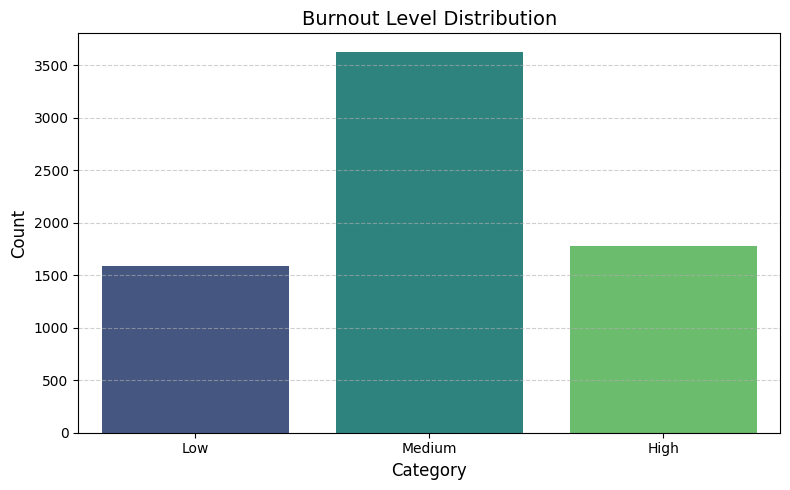


[INFO] Descriptive statistics summary:

                        count       mean        std        min        25%  \
age                    7000.0  32.126857   7.157599  20.000000  26.000000   
experience_years       7000.0   9.589429   5.703364   0.000000   5.000000   
daily_work_hours       7000.0   9.000071   2.835156   4.000000   6.607500   
sleep_hours            7000.0   6.485126   1.430488   4.000000   5.250000   
caffeine_intake        7000.0   3.549857   2.261406   0.000000   2.000000   
bugs_per_day           7000.0   9.473000   5.694249   0.000000   5.000000   
commits_per_day        7000.0  14.449286   8.582937   0.000000   7.000000   
meetings_per_day       7000.0   4.554143   2.828768   0.000000   2.000000   
screen_time            7000.0  11.975677   3.060138   5.210000   9.520000   
exercise_hours         7000.0   1.007859   0.570913   0.000000   0.520000   
stress_level           7000.0  53.655669  23.210980   0.000000  36.997500   
burnout_level          7000.0   1.0

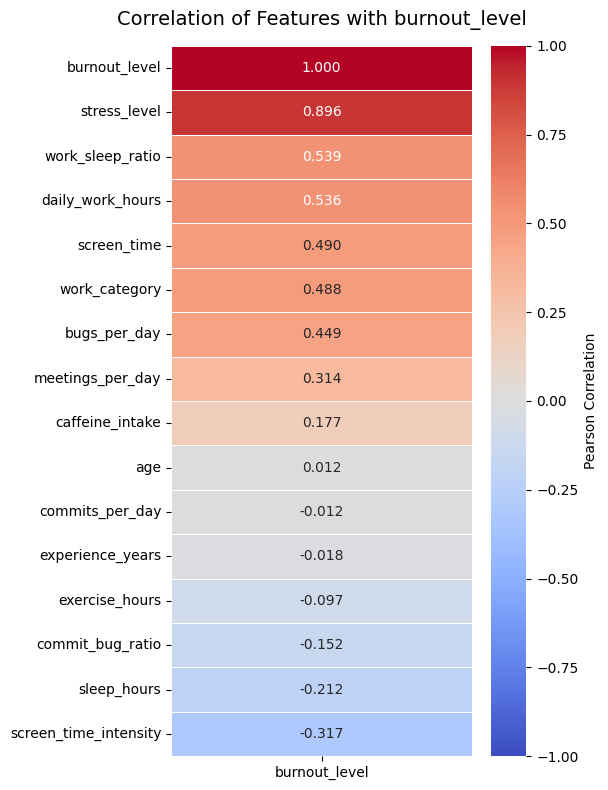

In [ ]:
# Data structure
print(f"[INFO] Dataset structure and data types:")
dtype_df = df_raw.dtypes.reset_index()
dtype_df.columns = ['Column', 'Type']
print(dtype_df.to_string(index=False))

# Target distribution
print(f"\n[INFO] Target distribution for '{TARGET_COLUMN}':")
target_dist = df_raw[TARGET_COLUMN].value_counts().sort_index()
for idx, count in target_dist.items():
    label      = CLASS_LABELS.get(idx, f"Class {idx}")
    percentage = (count / len(df_raw)) * 100
    print(f"  {label:<10}: {count:>5} ({percentage:>5.2f}%)")

plt.figure(figsize=(8, 5))
sns.barplot(
    x=[CLASS_LABELS[i] for i in target_dist.index],
    y=target_dist.values,
    palette='viridis'
)
plt.title('Burnout Level Distribution', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Descriptive statistics
print(f"\n[INFO] Descriptive statistics summary:\n")
print(df_raw.describe().T)
print()

# Correlation heatmap
numeric_cols = [col for col in df_raw.columns if df_raw[col].dtype != 'object']
correlations = df_raw[numeric_cols].corr()[[TARGET_COLUMN]].sort_values(by=TARGET_COLUMN, ascending=False)
plt.figure(figsize=(6, 8))
sns.heatmap(
    correlations, annot=True, cmap='coolwarm', fmt=".3f",
    vmin=-1, vmax=1, linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation'}
)
plt.title(f'Correlation of Features with {TARGET_COLUMN}', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


# 6. Data Preprocessing

In [ ]:
print("[INFO] Handling outliers...")
if OUTLIER_COL in df_raw.columns:
    clip_value = df_raw[OUTLIER_COL].quantile(OUTLIER_CLIP_Q)
    df_raw[OUTLIER_COL] = df_raw[OUTLIER_COL].clip(upper=clip_value)
    print(f"  Clipped '{OUTLIER_COL}' at {OUTLIER_CLIP_Q} quantile: {clip_value:.4f}")

X = df_raw.drop(columns=[TARGET_COLUMN])
y = df_raw[TARGET_COLUMN].values

print(f"\n[INFO] Feature-target separation completed.")
print(f"  Features shape : {X.shape}")
print(f"  Target shape   : {y.shape}")
print(f"  Feature columns: {list(X.columns)}")


[INFO] Handling outliers...
  Clipped 'commit_bug_ratio' at 0.99 quantile: 220.0000

[INFO] Feature-target separation completed.
  Features shape : (7000, 15)
  Target shape   : (7000,)
  Feature columns: ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level', 'work_sleep_ratio', 'screen_time_intensity', 'commit_bug_ratio', 'work_category']


# 7. Dataset Splitting

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print("[INFO] Dataset split completed")
print_split_summary(X_train, X_val, X_test)

print("\n[INFO] Class distribution per split:")
for split_name, split_y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    unique, counts = np.unique(split_y, return_counts=True)
    dist_str = ", ".join([f"{CLASS_LABELS[u]}: {c}" for u, c in zip(unique, counts)])
    print(f"  {split_name:<10}: {dist_str}")


[INFO] Dataset split completed

  Split             Samples   Percentage
  --------------------------------------
  Train                4900        70.0%
  Validation           1050        15.0%
  Test                 1050        15.0%
  --------------------------------------
  Total                7000       100.0%

[INFO] Class distribution per split:
  Train     : Low: 1115, Medium: 2537, High: 1248
  Val       : Low: 239, Medium: 544, High: 267
  Test      : Low: 239, Medium: 544, High: 267


# 8. Feature Scaling

In [ ]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("[INFO] Feature scaling completed using RobustScaler")
print(f"[INFO] Train scaled shape : {X_train_scaled.shape}")
print(f"[INFO] Val scaled shape   : {X_val_scaled.shape}")
print(f"[INFO] Test scaled shape  : {X_test_scaled.shape}")


[INFO] Feature scaling completed using RobustScaler
[INFO] Train scaled shape : (4900, 15)
[INFO] Val scaled shape   : (1050, 15)
[INFO] Test scaled shape  : (1050, 15)


# 9. Class Imbalance Handling (SMOTE)

[INFO] Applying SMOTE to handle class imbalance...
[INFO] SMOTE completed successfully.
[INFO] Original train size: 4900
[INFO] Balanced train size: 7611


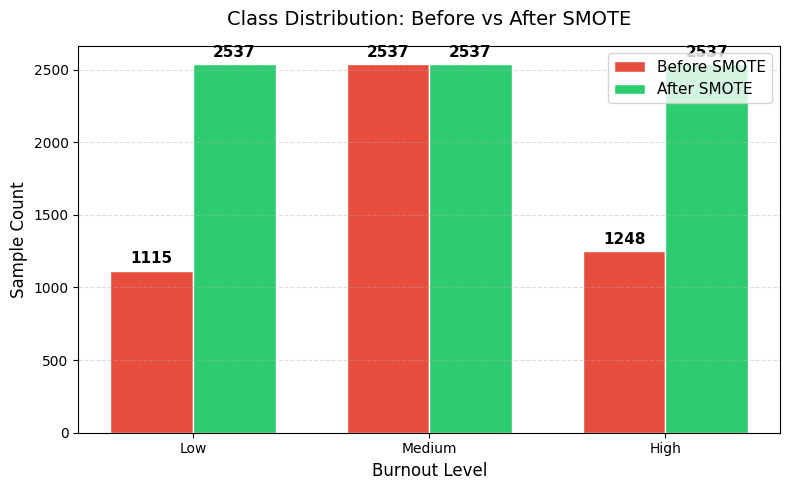


[INFO] Computed class weights:
[INFO] Class 0 (Low): 1.0000
[INFO] Class 1 (Medium): 1.0000
[INFO] Class 2 (High): 1.0000


In [ ]:
print("[INFO] Applying SMOTE to handle class imbalance...")

unique_before, counts_before = np.unique(y_train, return_counts=True)

smote = BorderlineSMOTE(random_state=RANDOM_SEED, kind='borderline-1')
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

unique_after, counts_after = np.unique(y_train_balanced, return_counts=True)

print(f"[INFO] SMOTE completed successfully.")
print(f"[INFO] Original train size: {len(X_train_scaled)}")
print(f"[INFO] Balanced train size: {len(X_train_balanced)}")

labels   = [CLASS_LABELS[u] for u in unique_before]
x_pos    = np.arange(len(labels))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x_pos - bar_width/2, counts_before, bar_width, label='Before SMOTE', color='#e74c3c', edgecolor='white')
bars2 = ax.bar(x_pos + bar_width/2, counts_after,  bar_width, label='After SMOTE',  color='#2ecc71', edgecolor='white')
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Class Distribution: Before vs After SMOTE', fontsize=14, pad=15)
ax.set_xlabel('Burnout Level', fontsize=12)
ax.set_ylabel('Sample Count', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_balanced),
    y=y_train_balanced
)

class_weights_list = class_weights.tolist()

print("\n[INFO] Computed class weights:")
for i, weight in enumerate(class_weights_list):
    print(f"[INFO] Class {i} ({CLASS_LABELS[i]}): {weight:.4f}")


# 10. Input Pipeline — tf.data

In [ ]:
# Convert labels to categorical (one-hot)
y_train_cat = tf.keras.utils.to_categorical(y_train_balanced, NUM_CLASSES)
y_val_cat   = tf.keras.utils.to_categorical(y_val, NUM_CLASSES)
y_test_cat  = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

# TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_balanced, y_train_cat))
train_dataset = train_dataset.shuffle(buffer_size=1024, seed=RANDOM_SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val_scaled, y_val_cat))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test_scaled, y_test_cat))
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

INPUT_SIZE   = X_train_balanced.shape[1]
FEATURE_COLS = X.columns.tolist()

print("[INFO] tf.data pipeline created")
print(f"[INFO] Input size    : {INPUT_SIZE}")
print(f"[INFO] Train batches : {len(train_dataset)}")
print(f"[INFO] Val batches   : {len(val_dataset)}")
print(f"[INFO] Test batches  : {len(test_dataset)}")

[INFO] tf.data pipeline created
[INFO] Input size    : 15
[INFO] Train batches : 119
[INFO] Val batches   : 17
[INFO] Test batches  : 17


# 11. Custom Loss Function

In [ ]:
class WeightedCategoricalCrossentropy(tf.keras.losses.Loss):
    """
    Custom Loss: cross-entropy dengan bobot per kelas.

    Kelas minoritas diberi penalti lebih besar sehingga model
    tidak terlalu bias ke kelas mayoritas.

    Args:
        class_weights: List bobot [w0, w1, w2] untuk kelas Low/Medium/High.
        label_smoothing: Faktor label smoothing (0.0–1.0).
    """
    def __init__(self, class_weights: list = None, label_smoothing: float = 0.0, **kwargs):
        super().__init__(**kwargs)
        weights = class_weights if class_weights is not None else [1.0, 1.0, 1.0]
        self.class_weights  = tf.constant(weights, dtype=tf.float32)
        self.label_smoothing = tf.constant(label_smoothing, dtype=tf.float32)

    def call(self, y_true, y_pred):
        y_true    = tf.cast(y_true, tf.int32)
        y_pred    = tf.clip_by_value(y_pred, 1e-7, 1.0)
        y_onehot  = tf.one_hot(y_true, depth=NUM_CLASSES)
        y_smoothed = y_onehot * (1.0 - self.label_smoothing) + (self.label_smoothing / NUM_CLASSES)
        ce        = -tf.reduce_sum(y_smoothed * tf.math.log(y_pred), axis=-1)
        sample_w  = tf.gather(self.class_weights, y_true)
        return tf.reduce_mean(ce * sample_w)

    def get_config(self):
        config = super().get_config()
        config.update({
            "class_weights":  self.class_weights.numpy().tolist(),
            "label_smoothing": self.label_smoothing.numpy().item()
        })
        return config

print("[OK] Custom Loss berhasil diimplementasikan.")

[OK] Custom Loss berhasil diimplementasikan.


# 12. Custom Callback

In [ ]:
class BurnAwayEarlyStopping(tf.keras.callbacks.Callback):
    """
    Custom Callback: hentikan training saat target akurasi tercapai.

    Kondisi stop: val_accuracy >= target_accuracy.
    Model yang disimpan adalah epoch dengan val_loss terkecil.
    Dilengkapi patience untuk menghindari stop terlalu dini.

    Args:
        target_accuracy: Threshold akurasi minimum untuk early stopping.
        save_path: Path untuk menyimpan model terbaik.
        patience: Jumlah epoch tanpa improvement sebelum stop.
    """
    def __init__(self, target_accuracy: float = 0.85, save_path: str = str(MODEL_BEST_PATH), patience: int = 5):
        super().__init__()
        self.target_accuracy = target_accuracy
        self.save_path       = save_path
        self.best_val_loss   = float("inf")
        self.best_epoch      = -1
        self.patience        = patience
        self.wait            = 0
        self._should_stop    = False

    def on_epoch_end(self, epoch, logs=None):
        logs     = logs or {}
        val_acc  = logs.get("val_accuracy", 0.0)
        val_loss = logs.get("val_loss", float("inf"))

        msg = ""

        if epoch >= MIN_EPOCHS_BEFORE_SAVE and val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.best_epoch    = epoch + 1
            self.wait          = 0
            self.model.save(self.save_path)
            msg += f"  [CHECKPOINT] Model Tersimpan"
        else:
            self.wait += 1

        if val_acc >= self.target_accuracy:
            msg += f"  [TARGET ACHIEVED]"

        if self.wait >= self.patience and epoch >= MIN_EPOCHS_BEFORE_SAVE:
            msg += f"  [EARLY STOP] (Best: Ep {self.best_epoch})"
            self.model.stop_training = True
            self._should_stop = True

        return msg

print("[OK] Custom Callback berhasil diimplementasikan.")

[OK] Custom Callback berhasil diimplementasikan.


# 13. Custom Layer

In [ ]:
class BurnoutAttentionLayer(tf.keras.layers.Layer):
    """
    Custom Layer: soft attention berbasis fitur tabular.

    Menghitung skor kepentingan tiap fitur via tanh + softmax,
    lalu mengalikan representasi fitur dengan skor tersebut.

    Args:
        units: Dimensi ruang proyeksi attention.
    """
    def __init__(self, units: int = 32, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer="glorot_uniform", trainable=True, name="attention_kernel"
        )
        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros", trainable=True, name="attention_bias"
        )
        self.attention_v = self.add_weight(
            shape=(self.units, 1),
            initializer="glorot_uniform", trainable=True, name="attention_v"
        )

    def call(self, inputs):
        score             = tf.nn.tanh(tf.matmul(inputs, self.w) + self.b)
        attention_weights = tf.nn.softmax(tf.matmul(score, self.attention_v), axis=-1)
        return inputs * attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config

print("[OK] Custom Layer berhasil diimplementasikan.")

[OK] Custom Layer berhasil diimplementasikan.


# 14. Model Architecture

In [ ]:
set_global_seed(RANDOM_SEED)

def build_burnaway_model(input_shape: int, num_classes: int) -> Model:
    """
    Model klasifikasi single-output dengan BurnoutAttentionLayer dan Residual Connections.

    Arsitektur:
        Input → BurnoutAttentionLayer
             → Dense(128) → BN → Swish ─┐
             → Dense(128) → BN → Swish  ├─ Add() → Dropout(0.15)
             → Dense(64)  → BN → Swish → Dropout(0.10)
             → Dense(32)  → Swish → Dense(16) → Swish
             → Dense(num_classes, softmax)

    Args:
        input_shape: Jumlah fitur input.
        num_classes: Jumlah kelas output.

    Returns:
        tf.keras.Model single output (classification only).
    """
    inputs = layers.Input(shape=(input_shape,), name='input_features')

    x = BurnoutAttentionLayer(units=ATTENTION_UNITS, name="attention_layer")(inputs)

    # Residual block
    x1 = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(L2_REG_FACTOR))(x)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Activation('swish')(x1)

    x2 = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(L2_REG_FACTOR))(x1)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Activation('swish')(x2)
    x  = layers.Add()([x1, x2])
    x  = layers.Dropout(DROPOUT_RATES[0])(x)

    # Shared representation
    x = layers.Dense(64, activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATES[1])(x)

    # Classification head
    x = layers.Dense(32, activation='swish')(x)
    x = layers.Dense(16, activation='swish')(x)
    output = layers.Dense(num_classes, activation='softmax', name='classification_output')(x)

    return Model(inputs=inputs, outputs=output, name='BurnAway_Classification_Model')

model = build_burnaway_model(INPUT_SIZE, NUM_CLASSES)
model.summary()


Model: "BurnAway_Classification_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 15)        │      1,088 │ input_features[0… │
│ (BurnoutAttentionL… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      2,048 │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ activation[0][0], │
│                     │                   │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │        528 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification_out… │ (None, 3)         │         51 │ dense_4[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,843 (124.39 KB)

 Trainable params: 31,203 (121.89 KB)

 Non-trainable params: 640 (2.50 KB)

# 15. K-Fold Cross-Validation

In [ ]:
loss_fn_clf = WeightedCategoricalCrossentropy(
    class_weights=class_weights_list,
    label_smoothing=LABEL_SMOOTHING
)

def run_kfold_validation(x_data: np.ndarray, y_labels: np.ndarray, n_splits: int = 5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)

    print(f"[INFO] Starting {n_splits}-Fold Cross-Validation...\n")
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(x_data, y_labels)):
        x_train_fold = x_data[train_idx]
        x_val_fold   = x_data[val_idx]
        y_train_fold = y_labels[train_idx]
        y_val_fold   = y_labels[val_idx]

        # SMOTE hanya pada data training fold
        sm = SMOTE(random_state=RANDOM_SEED)
        x_resampled, y_resampled = sm.fit_resample(x_train_fold, y_train_fold)

        train_ds = create_tf_dataset(x_resampled, y_resampled, is_training=True)
        val_ds   = create_tf_dataset(x_val_fold,  y_val_fold,  is_training=False)

        fold_model = build_burnaway_model(INPUT_SIZE, NUM_CLASSES)
        fold_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss=loss_fn_clf,
            metrics=['accuracy']
        )

        hist = fold_model.fit(train_ds, validation_data=val_ds, epochs=10, verbose=0)

        val_acc = max(hist.history['val_accuracy'])
        fold_scores.append(val_acc)

        print(f" Fold {fold+1}/{n_splits} | Train: {len(x_resampled):<4} | Val: {len(x_val_fold):<4} | Val. Accuracy: {val_acc:.4f}")

    print(f"  [OK] K-Fold Validation Finished!")
    print(f"[INFO] Average Validation Accuracy: {np.mean(fold_scores):.4f} \u00b1 {np.std(fold_scores):.4f}\n")

    return fold_scores

fold_scores = run_kfold_validation(X_train_scaled, y_train, n_splits=5)


[INFO] Starting 5-Fold Cross-Validation...

 Fold 1/5 | Train: 6087 | Val: 980  | Val. Accuracy: 0.7520
 Fold 2/5 | Train: 6087 | Val: 980  | Val. Accuracy: 0.8000
 Fold 3/5 | Train: 6090 | Val: 980  | Val. Accuracy: 0.8051
 Fold 4/5 | Train: 6090 | Val: 980  | Val. Accuracy: 0.7888
 Fold 5/5 | Train: 6090 | Val: 980  | Val. Accuracy: 0.7939
  [OK] K-Fold Validation Finished!
[INFO] Average Validation Accuracy: 0.7880 ± 0.0188



# 16. Optimizer & Training Configuration

In [ ]:
total_steps = EPOCHS * (len(X_train_balanced) // BATCH_SIZE)
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LEARNING_RATE,
    decay_steps=total_steps,
    alpha=1e-5
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=GRAD_CLIP)

loss_fn_clf = WeightedCategoricalCrossentropy(
    class_weights=class_weights_list,
    label_smoothing=LABEL_SMOOTHING
)

train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')
val_acc_metric   = tf.keras.metrics.SparseCategoricalAccuracy(name='val_accuracy')

print(f"[INFO] Konfigurasi Optimizer & Loss selesai.")
print(f"[INFO] Scheduler      : CosineDecayRestarts")
print(f"[INFO] Initial LR     : {LEARNING_RATE}")
print(f"[INFO] Loss           : WeightedCategoricalCrossentropy")


[INFO] Konfigurasi Optimizer & Loss selesai.
[INFO] Scheduler      : CosineDecayRestarts
[INFO] Initial LR     : 0.0005
[INFO] Loss           : WeightedCategoricalCrossentropy


# 17. TensorBoard Monitoring

In [ ]:
tb_writer = tf.summary.create_file_writer(str(LOG_DIR))

def log_to_tensorboard(epoch: int, metrics: dict) -> None:
    """Menulis metrik training ke TensorBoard log directory."""
    with tb_writer.as_default():
        for name, value in metrics.items():
            tf.summary.scalar(name, data=value, step=epoch)
        tb_writer.flush()

print(f'[INFO] TensorBoard log directory : {LOG_DIR}')
print(f'[INFO] Jalankan perintah berikut untuk membuka TensorBoard:')
print(f'       %tensorboard --logdir {LOG_DIR}')

try:
    from google.colab import output
    output.serve_kernel_port_as_iframe(6006)
    print('[INFO] TensorBoard iframe aktif di Colab.')
except Exception:
    print('[INFO] Mode lokal: Jalankan tensorboard --logdir dari terminal.')


[INFO] TensorBoard log directory : logs/fit/20260523-061429
[INFO] Jalankan perintah berikut untuk membuka TensorBoard:
       %tensorboard --logdir logs/fit/20260523-061429


<IPython.core.display.Javascript object>

[INFO] TensorBoard iframe aktif di Colab.


# 18. Custom Training Loop

In [ ]:
@tf.function
def train_step(x, y_clf):
    with tf.GradientTape() as tape:
        clf_probs    = model(x, training=True)
        y_clf_sparse = tf.argmax(y_clf, axis=-1)
        loss_clf     = loss_fn_clf(y_clf_sparse, clf_probs)

    gradients, _ = tf.clip_by_global_norm(tape.gradient(loss_clf, model.trainable_variables), GRAD_CLIP)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    train_acc_metric.update_state(y_clf_sparse, clf_probs)
    return loss_clf

@tf.function
def val_step(x, y_clf):
    clf_probs    = model(x, training=False)
    y_clf_sparse = tf.argmax(y_clf, axis=-1)
    loss_clf     = loss_fn_clf(y_clf_sparse, clf_probs)
    val_acc_metric.update_state(y_clf_sparse, clf_probs)
    return loss_clf

# Inisialisasi history dan callback
history        = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
early_stopping = BurnAwayEarlyStopping(target_accuracy=TARGET_ACCURACY, save_path=str(MODEL_BEST_PATH), patience=10)
early_stopping.set_model(model)

print("[INFO] Training Started...\n")

for epoch in range(EPOCHS):
    train_acc_metric.reset_state()
    val_acc_metric.reset_state()
    train_loss = val_loss = 0.0
    train_batches = val_batches = 0

    for x_batch, y_batch in train_dataset:
        train_loss += train_step(x_batch, y_batch)
        train_batches += 1

    for x_batch, y_batch in val_dataset:
        val_loss += val_step(x_batch, y_batch)
        val_batches += 1

    avg_train_loss = train_loss / train_batches
    avg_val_loss   = val_loss / val_batches

    t_acc = train_acc_metric.result().numpy()
    v_acc = val_acc_metric.result().numpy()

    history['loss'].append(float(avg_train_loss))
    history['val_loss'].append(float(avg_val_loss))
    history['accuracy'].append(float(t_acc))
    history['val_accuracy'].append(float(v_acc))

    logs = {
        'val_loss': avg_val_loss,
        'val_accuracy': v_acc
    }

    msg = early_stopping.on_epoch_end(epoch, logs)

    status = ""
    if msg:
        if "CHECKPOINT" in msg:
            status += " [Saved]"
        if "TARGET ACHIEVED" in msg:
            status += " [Achieved]"

    print(
        f"[{epoch+1:03d}/{EPOCHS:03d}] "
        f"Train Loss: {float(avg_train_loss):.4f} | "
        f"Train Acc: {t_acc*100:.2f}% | "
        f"Val Loss: {float(avg_val_loss):.4f} | "
        f"Val Acc: {v_acc*100:.2f}% |"
        f"{status}"
    )

    log_to_tensorboard(epoch, {
        'loss': avg_train_loss,
        'accuracy': t_acc,
        'val_loss': avg_val_loss,
        'val_accuracy': v_acc
    })

    if early_stopping._should_stop:
        print("\n[WARNING] Early stopping triggered!")
        break

print(f"\n[INFO] Training Finished")
print(f"[INFO] Best Epoch : {early_stopping.best_epoch}")
print(f"[INFO] Best Val Loss : {early_stopping.best_val_loss:.4f}")

[INFO] Training Started...

[001/100] Train Loss: 0.7574 | Train Acc: 69.95% | Val Loss: 0.8029 | Val Acc: 68.67% |
[002/100] Train Loss: 0.7059 | Train Acc: 71.82% | Val Loss: 0.6587 | Val Acc: 71.90% |
[003/100] Train Loss: 0.6536 | Train Acc: 74.33% | Val Loss: 0.6475 | Val Acc: 72.10% |
[004/100] Train Loss: 0.6353 | Train Acc: 74.33% | Val Loss: 0.6309 | Val Acc: 73.33% |
[005/100] Train Loss: 0.6302 | Train Acc: 75.25% | Val Loss: 0.6262 | Val Acc: 73.52% |
[006/100] Train Loss: 0.6159 | Train Acc: 76.06% | Val Loss: 0.5478 | Val Acc: 80.86% |
[007/100] Train Loss: 0.6082 | Train Acc: 76.53% | Val Loss: 0.5596 | Val Acc: 78.48% |
[008/100] Train Loss: 0.6062 | Train Acc: 76.53% | Val Loss: 0.5808 | Val Acc: 77.71% |
[009/100] Train Loss: 0.6115 | Train Acc: 76.13% | Val Loss: 0.5369 | Val Acc: 80.95% |
[010/100] Train Loss: 0.5901 | Train Acc: 77.52% | Val Loss: 0.5523 | Val Acc: 79.33% |
[011/100] Train Loss: 0.5707 | Train Acc: 78.58% | Val Loss: 0.5439 | Val Acc: 79.62% | [Sav

# 19. Training History Visualization

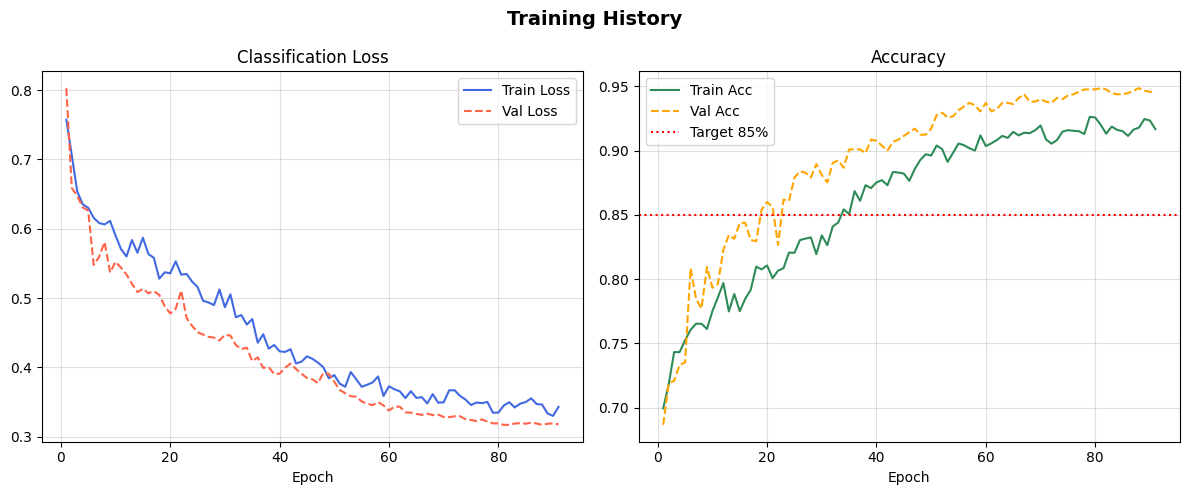


[BEST]   Epoch 81 | Val Acc: 0.9486
[STATUS] Accuracy: 94.86% [ACHIEVED]


In [ ]:
def plot_training_history(history: dict) -> None:
    epochs_range = range(1, len(history['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Training History', fontsize=14, fontweight='bold')

    axes[0].plot(epochs_range, history['loss'],     label='Train Loss',  color='royalblue')
    axes[0].plot(epochs_range, history['val_loss'], label='Val Loss',    color='tomato', linestyle='--')
    axes[0].set_title('Classification Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.4)

    axes[1].plot(epochs_range, history['accuracy'],     label='Train Acc', color='seagreen')
    axes[1].plot(epochs_range, history['val_accuracy'], label='Val Acc',   color='orange', linestyle='--')
    axes[1].axhline(TARGET_ACCURACY, color='red', linestyle=':', label=f'Target {TARGET_ACCURACY*100:.0f}%')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.4)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

best_epoch = int(np.argmax(history['val_accuracy'])) + 1
best_acc   = max(history['val_accuracy'])
print(f'\n[BEST]   Epoch {best_epoch} | Val Acc: {best_acc:.4f}')
print(f'[STATUS] {check_target_achieved(best_acc)}')

# Load model terbaik
model = tf.keras.models.load_model(
    str(MODEL_BEST_PATH),
    custom_objects={
        "BurnoutAttentionLayer":        BurnoutAttentionLayer,
        "WeightedCategoricalCrossentropy": WeightedCategoricalCrossentropy,
    }
)


# 20. Final Evaluation

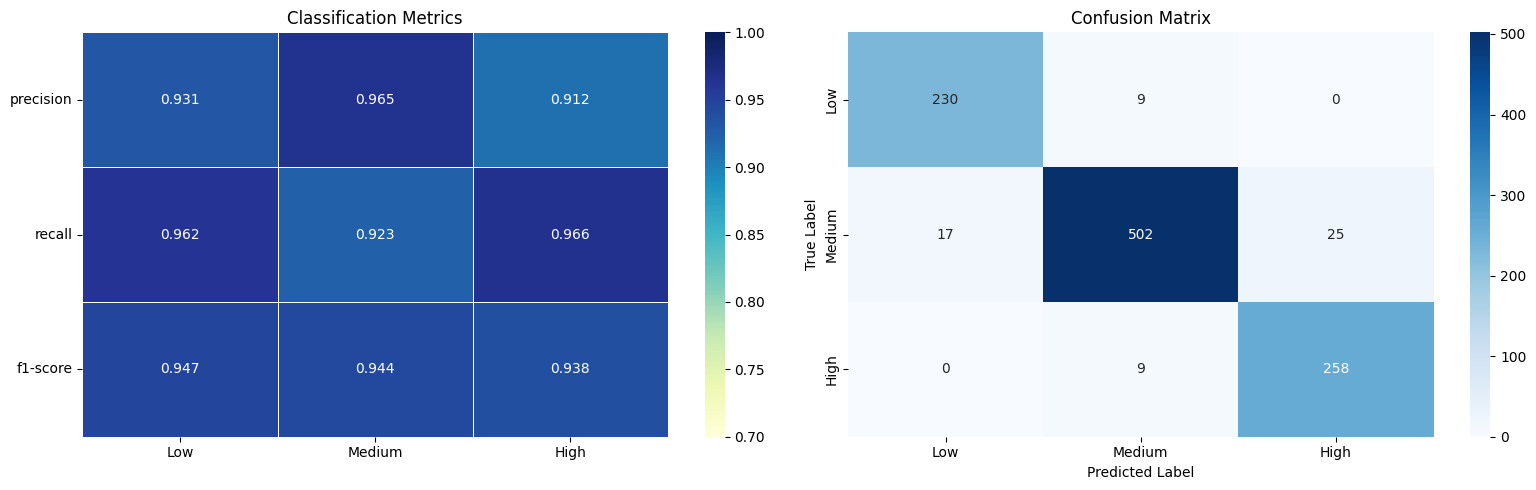


[STATUS] Test Acc: 94.29%
[STATUS] Accuracy: 94.29% [ACHIEVED]


In [ ]:
def evaluate_final_model(eval_model, eval_test_dataset, class_labels):
    """Evaluasi komprehensif pada data tes."""

    all_y_clf, all_pred_clf = [], []

    for x, y_clf in eval_test_dataset:
        clf_probs = eval_model(x, training=False)
        pred_clf  = tf.argmax(clf_probs, axis=1)

        all_y_clf.extend(tf.argmax(y_clf, axis=1).numpy())
        all_pred_clf.extend(pred_clf.numpy())

    report_dict = classification_report(
        all_y_clf,
        all_pred_clf,
        target_names=list(class_labels.values()),
        output_dict=True
    )

    classes    = list(class_labels.values())
    metrics_df = pd.DataFrame(report_dict)[classes].T

    cm = confusion_matrix(all_y_clf, all_pred_clf)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Classification Metrics
    sns.heatmap(
        metrics_df[['precision', 'recall', 'f1-score']].T,
        annot=True,
        cmap='YlGnBu',
        fmt='.3f',
        vmin=0.7,
        vmax=1.0,
        linewidths=0.5,
        ax=axes[0]
    )

    axes[0].set_title('Classification Metrics')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].tick_params(axis='y', rotation=0)

    # Confusion Matrix
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels.values(),
        yticklabels=class_labels.values(),
        ax=axes[1]
    )

    axes[1].set_title('Confusion Matrix')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.tight_layout()
    plt.show()

    test_acc = np.mean(np.array(all_y_clf) == np.array(all_pred_clf))

    print(f"\n[STATUS] Test Acc: {test_acc:.2%}")
    print(f"[STATUS] {check_target_achieved(test_acc)}")

evaluate_final_model(model, test_dataset, CLASS_LABELS)

# 21. Inference Pipeline

In [ ]:
def predict_burnout(raw_input: dict, inference_model=None, inference_scaler=None) -> dict:
    inf_model  = inference_model  or model
    inf_scaler = inference_scaler or scaler

    missing = [c for c in FEATURE_COLS if c not in raw_input]
    if missing:
        raise ValueError(f'[ERROR] Fitur berikut tidak ditemukan dalam input: {missing}')

    x_raw = np.array([[raw_input[c] for c in FEATURE_COLS]], dtype=np.float32)

    cbr_idx = FEATURE_COLS.index('commit_bug_ratio') if 'commit_bug_ratio' in FEATURE_COLS else -1
    if cbr_idx >= 0:
        x_raw[0, cbr_idx] = min(x_raw[0, cbr_idx], 220.0)

    x_scaled  = inf_scaler.transform(x_raw).astype(np.float32)
    clf_probs  = inf_model.predict(x_scaled, verbose=0)
    probs      = clf_probs[0]
    pred_cls   = int(np.argmax(probs))

    return {
        'label':       CLASS_LABELS[pred_cls],
        'confidence':  float(probs[pred_cls]),
        'class_probs': {CLASS_LABELS[i]: float(p) for i, p in enumerate(probs)},
    }


# Demo inference
user_context = {
    "name": "Budi",
    "work_hours": 11.5,
    "role": "Backend Engineer"
}

sample_input = {
    'age': 28.0, 'experience_years': 3.0, 'daily_work_hours': 11.5,
    'sleep_hours': 5.2, 'caffeine_intake': 5.0, 'bugs_per_day': 14.0,
    'commits_per_day': 7.0, 'meetings_per_day': 6.0, 'screen_time': 13.5,
    'exercise_hours': 0.3, 'work_sleep_ratio': 2.21,
    'screen_time_intensity': 1.17, 'commit_bug_ratio': 0.5,
    'work_category': 1.0, 'stress_level': 5.0
}

prediction = predict_burnout(sample_input, inference_model=model, inference_scaler=scaler)
print(f"[INFO] Model Berhasil Membuat Prediksi\n")
print(f'Label          : {prediction["label"]}')
print(f'Confidence     : {prediction["confidence"]:.2%}')
print(f'Class Probs    : { {k: f"{v:.2%}" for k, v in prediction["class_probs"].items()} }')


[INFO] Model Berhasil Membuat Prediksi

Label          : Low
Confidence     : 55.92%
Class Probs    : {'Low': '55.92%', 'Medium': '30.15%', 'High': '13.93%'}


# 22. Generative AI Advisory Layer

In [ ]:
def build_advisory_prompt(prediction_result: dict, user_context: dict = None) -> str:
    label       = prediction_result['label']
    confidence  = prediction_result['confidence']
    class_probs = prediction_result['class_probs']

    context_str = ""
    if user_context:
        name       = user_context.get("name", "Developer")
        work_hours = user_context.get("work_hours", None)
        role       = user_context.get("role", None)

        context_str = f"Developer yang dianalisis bernama {name}."
        if work_hours:
            context_str += f" Ia bekerja rata-rata {work_hours} jam per hari."
        if role:
            context_str += f" Role-nya adalah {role}."

    return (
        f"Kamu adalah asisten kesehatan mental profesional untuk developer perangkat lunak.\n"
        f"{context_str}\n"
        f"Berdasarkan analisis AI, developer ini terdeteksi berada di level burnout: **{label}** "
        f"(confidence: {confidence:.1%}).\n"
        f"Distribusi probabilitas kelas: {class_probs}.\n\n"
        f"Berikan 5 rekomendasi konkret dan personal dalam bahasa Indonesia yang:\n"
        f"1. Spesifik untuk level burnout '{label}'\n"
        f"2. Dapat langsung diterapkan oleh developer\n"
        f"3. Mencakup aspek: manajemen waktu, kesehatan fisik, dan produktivitas\n"
        f"Tutup dengan kalimat motivasi singkat."
    )


def get_burnout_advice_sdk(prompt: str) -> str:
    client   = genai.Client(api_key=GEMINI_API_KEY)
    response = client.models.generate_content(model=GEMINI_MODEL, contents=prompt)
    return response.text


def get_burnout_advice_rest(prompt: str) -> str:
    if not GEMINI_API_KEY:
        return '[INFO] GEMINI_API_KEY tidak ditemukan.'
    url     = f'{GEMINI_BASE_URL}/{GEMINI_MODEL}:generateContent?key={GEMINI_API_KEY}'
    payload = {
        'contents': [{'parts': [{'text': prompt}]}],
        'generationConfig': {'temperature': 0.7, 'maxOutputTokens': 1024},
    }
    resp = requests.post(url, json=payload, timeout=30)
    resp.raise_for_status()
    return resp.json()['candidates'][0]['content']['parts'][0]['text']


def get_burnout_advice_groq(prompt: str) -> str:
    if not GROQ_API_KEY:
        raise ValueError("GROQ_API_KEY tidak ditemukan.")
    url     = f'{GROQ_BASE_URL}chat/completions'
    headers = {"Authorization": f"Bearer {GROQ_API_KEY}", "Content-Type": "application/json"}
    payload = {
        'model': GROQ_MODEL,
        'messages': [{'role': 'user', 'content': prompt}],
        'temperature': 0.7,
        'max_tokens': 1024,
    }
    try:
        resp = requests.post(url, headers=headers, json=payload, timeout=30)
        resp.raise_for_status()
        return resp.json()['choices'][0]['message']['content']
    except Exception as e:
        return f'[GROQ API ERROR] {str(e)}'


def _offline_fallback(label: str) -> str:
    label = label.lower()
    if label == "high":
        return (
            "Tingkat burnout Anda TINGGI.\n"
            "1. Segera jadwalkan waktu istirahat atau cuti panjang.\n"
            "2. Diskusikan pendelegasian tugas dengan manajer.\n"
            "3. Cari bantuan profesional (psikolog/konselor) jika kewalahan.\n"
            "4. Batasi jam kerja secara ketat, hindari membuka pekerjaan di luar jam kantor.\n"
            "5. Lakukan aktivitas fisik ringan setiap hari, minimal jalan kaki santai.\n\n"
            "Kesehatan mentalmu jauh lebih berharga daripada tenggat waktu mana pun. Istirahatlah!"
        )
    elif label == "medium":
        return (
            "Tingkat burnout Anda SEDANG.\n"
            "1. Rapikan manajemen waktu dengan metode Pomodoro atau Timeblocking.\n"
            "2. Hindari lembur yang tidak perlu, kenali batas energimu.\n"
            "3. Gunakan akhir pekan untuk hobi dan kegiatan yang merilekskan pikiran.\n"
            "4. Sempatkan peregangan kecil dan istirahat mata (aturan 20-20-20).\n"
            "5. Katakan 'tidak' pada tugas tambahan jika kapasitasmu sudah penuh.\n\n"
            "Cegah burnout sebelum semakin parah dengan mulai mengatur keseimbangan hidup."
        )
    else:
        return (
            "Tingkat burnout Anda RENDAH.\n"
            "1. Pertahankan rutinitas kerja dan work-life balance saat ini.\n"
            "2. Jaga pola makan, tidur, dan olahraga yang teratur.\n"
            "3. Tetap waspada jika beban kerja tiba-tiba meningkat tajam.\n"
            "4. Lanjutkan praktik manajemen waktu yang sudah berjalan baik.\n"
            "5. Berikan apresiasi kepada diri sendiri atas pekerjaan yang diselesaikan.\n\n"
            "Bagus sekali! Pertahankan energimu dan teruslah berkarya secara sehat."
        )


def get_burnout_advice(prediction_result: dict, primary: str = 'gemini', user_context: dict = None) -> tuple:
    prompt = build_advisory_prompt(prediction_result, user_context)

    def call_gemini():
        if GENAI_SDK_AVAILABLE and GEMINI_API_KEY:
            return get_burnout_advice_sdk(prompt), 'Gemini (SDK)'
        elif GEMINI_API_KEY:
            return get_burnout_advice_rest(prompt), 'Gemini (REST)'
        raise ValueError("GEMINI_API_KEY tidak tersedia")

    def call_groq():
        return get_burnout_advice_groq(prompt), 'Groq (REST)'

    try:
        return call_gemini() if primary == 'gemini' else call_groq()
    except Exception as e:
        print(f"[GENAI] WARNING! {primary.upper()} gagal ({e})")
        try:
            return call_groq() if primary == 'gemini' else call_gemini()
        except Exception as fe:
            fallback_api = 'GROQ' if primary == 'gemini' else 'GEMINI'
            print(f"[GENAI] WARNING! {fallback_api} juga gagal ({fe}).")
            return _offline_fallback(prediction_result.get('label', 'low')), "Offline (Rule-Based)"


advice, route = get_burnout_advice(prediction, primary='gemini', user_context=user_context)
print(f'[GENAI] Routing: {route} | Model: {GROQ_MODEL if "Groq" in route else GEMINI_MODEL}')
print(f'\nREKOMENDASI UNTUK {prediction["label"].upper()} BURNOUT')
print(f"\n", advice)

[GENAI] WARNING! GEMINI gagal (GEMINI_API_KEY tidak tersedia)
[GENAI] WARNING! GROQ juga gagal (GROQ_API_KEY tidak ditemukan.).
[GENAI] Routing: Offline (Rule-Based) | Model: gemini-2.5-flash

REKOMENDASI UNTUK LOW BURNOUT

 Tingkat burnout Anda RENDAH.
1. Pertahankan rutinitas kerja dan work-life balance saat ini.
2. Jaga pola makan, tidur, dan olahraga yang teratur.
3. Tetap waspada jika beban kerja tiba-tiba meningkat tajam.
4. Lanjutkan praktik manajemen waktu yang sudah berjalan baik.
5. Berikan apresiasi kepada diri sendiri atas pekerjaan yang diselesaikan.

Bagus sekali! Pertahankan energimu dan teruslah berkarya secara sehat.


# 23. Artifact Serialization & Export

In [ ]:
def save_model_artifacts(final_model, fit_scaler, feature_columns: list, class_map: dict) -> None:
    final_model.save(str(MODEL_FINAL_PATH))
    print(f'  [OK] Model final          → {MODEL_FINAL_PATH}')

    scaler_path = MODEL_SAVE_DIR / 'scaler.joblib'
    joblib.dump(fit_scaler, str(scaler_path))
    print(f'  [OK] RobustScaler         → {scaler_path}')

    feat_path = API_DIR / 'feature_cols.json'
    with open(feat_path, 'w', encoding='utf-8') as fp:
        _json.dump(feature_columns, fp, indent=2)
    print(f'  [OK] Feature columns      → {feat_path}')

    labels_path = API_DIR / 'class_labels.json'
    with open(labels_path, 'w', encoding='utf-8') as fp:
        _json.dump({str(k): v for k, v in class_map.items()}, fp, indent=2)
    print(f'  [OK] Class labels         → {labels_path}')

    config_path = API_DIR / 'pipeline_config.json'
    config_meta = {
        'num_features'   : len(feature_columns),
        'num_classes'    : NUM_CLASSES,
        'attention_units': ATTENTION_UNITS,
        'scaler_type'    : 'RobustScaler',
        'model_format'   : '.keras',
        'target_accuracy': TARGET_ACCURACY,
    }
    with open(config_path, 'w', encoding='utf-8') as fp:
        _json.dump(config_meta, fp, indent=2)
    print(f'  [OK] Pipeline config      → {config_path}')


save_model_artifacts(model, scaler, FEATURE_COLS, CLASS_LABELS)

print()
for artifact in [MODEL_BEST_PATH, MODEL_FINAL_PATH,
                 MODEL_SAVE_DIR / 'scaler.joblib',
                 API_DIR / 'feature_cols.json',
                 API_DIR / 'class_labels.json',
                 API_DIR / 'pipeline_config.json']:
    exists = 'OK' if artifact.exists() else 'MISSING'
    print(f'  [{exists}] {artifact}')

print(f'\n[OK] Semua artifact berhasil diekspor.')
print(f'     Pipeline BurnAway siap untuk deployment via FastAPI!')


  [OK] Model final          → models/burnaway_model.keras
  [OK] RobustScaler         → models/scaler.joblib
  [OK] Feature columns      → api/feature_cols.json
  [OK] Class labels         → api/class_labels.json
  [OK] Pipeline config      → api/pipeline_config.json

  [OK] models/burnaway_model_best.keras
  [OK] models/burnaway_model.keras
  [OK] models/scaler.joblib
  [OK] api/feature_cols.json
  [OK] api/class_labels.json
  [OK] api/pipeline_config.json

[OK] Semua artifact berhasil diekspor.
     Pipeline BurnAway siap untuk deployment via FastAPI!
